# 1 -Menghubungkan Google Colab dengan Google Drive,
Setelah dijalankan, Colab akan meminta otorisasi akun Google Drive. Ikuti instruksi sampai muncul pesan bahwa Google Drive sudah berhasil terhubung.

In [ ]:
from google.colab import drive
drive.mount('/content/drive')

Drive already mounted at /content/drive; to attempt to forcibly remount, call drive.mount("/content/drive", force_remount=True).


# 2- Menentukan Lokasi Dataset

Sumber Utama Dataset dari: https://www.kaggle.com/datasets/uciml/pima-indians-diabetes-database, Dataset tersebut didownload dan disimpan di google drive sesuai lokasi projek yang ditentukan

**Misalnya file dataset disimpan di Google Drive dengan struktur:**

MyDrive ─>PemrogramanBerbasisPlatform ->Project011-> AplikasiPrediksiDiabetes -> dataset - diabetes.csv:


In [ ]:
dataset_path = "/content/drive/MyDrive/PemrogramanBerbasisPlatform/Project011/AplikasiPrediksiDiabetes/dataset/diabetes.csv"

Note: Jika foldernya berbeda, sesuaikan path-nya

# 3- Membaca Dataset dari Google Drive

In [ ]:
import pandas as pd

df = pd.read_csv(dataset_path)
df.head()

,Pregnancies,Glucose,BloodPressure,SkinThickness,Insulin,BMI,DiabetesPedigreeFunction,Age,Outcome
0,6,148,72,35,0,33.6,0.627,50,1
1,1,85,66,29,0,26.6,0.351,31,0
2,8,183,64,0,0,23.3,0.672,32,1
3,1,89,66,23,94,28.1,0.167,21,0
4,0,137,40,35,168,43.1,2.288,33,1


Untuk memastikan dataset berhasil dibaca:

In [ ]:
df.info()

<class 'pandas.core.frame.DataFrame'>
RangeIndex: 768 entries, 0 to 767
Data columns (total 9 columns):
 #   Column                    Non-Null Count  Dtype  
---  ------                    --------------  -----  
 0   Pregnancies               768 non-null    int64  
 1   Glucose                   768 non-null    int64  
 2   BloodPressure             768 non-null    int64  
 3   SkinThickness             768 non-null    int64  
 4   Insulin                   768 non-null    int64  
 5   BMI                       768 non-null    float64
 6   DiabetesPedigreeFunction  768 non-null    float64
 7   Age                       768 non-null    int64  
 8   Outcome                   768 non-null    int64  
dtypes: float64(2), int64(7)
memory usage: 54.1 KB


In [ ]:
df.describe()

,Pregnancies,Glucose,BloodPressure,SkinThickness,Insulin,BMI,DiabetesPedigreeFunction,Age,Outcome
count,768.000000,768.000000,768.000000,768.000000,768.000000,768.000000,768.000000,768.000000,768.000000
mean,3.845052,120.894531,69.105469,20.536458,79.799479,31.992578,0.471876,33.240885,0.348958
std,3.369578,31.972618,19.355807,15.952218,115.244002,7.884160,0.331329,11.760232,0.476951
min,0.000000,0.000000,0.000000,0.000000,0.000000,0.000000,0.078000,21.000000,0.000000
25%,1.000000,99.000000,62.000000,0.000000,0.000000,27.300000,0.243750,24.000000,0.000000
50%,3.000000,117.000000,72.000000,23.000000,30.500000,32.000000,0.372500,29.000000,0.000000
75%,6.000000,140.250000,80.000000,32.000000,127.250000,36.600000,0.626250,41.000000,1.000000
max,17.000000,199.000000,122.000000,99.000000,846.000000,67.100000,2.420000,81.000000,1.000000


In [ ]:
df['Outcome'].value_counts()

,count
Outcome,
0,500
1,268


Note: Kolom Outcome adalah label target.

0 = Tidak diabetes

1 = Diabetes

# 4 - Import library utama

In [ ]:
import pandas as pd
import numpy as np

from sklearn.model_selection import train_test_split
from sklearn.preprocessing import StandardScaler
from sklearn.ensemble import RandomForestClassifier

from sklearn.metrics import accuracy_score
from sklearn.metrics import precision_score
from sklearn.metrics import recall_score
from sklearn.metrics import f1_score
from sklearn.metrics import confusion_matrix
from sklearn.metrics import classification_report

import pickle

# 5 - Memisahkan Fitur dan Label

In [ ]:
X = df.drop("Outcome", axis=1)
y = df["Outcome"]

Penjelasan:

X = data input untuk prediksi

y = label target yang ingin diprediksi

Contoh fitur:

In [ ]:
X.head()

,Pregnancies,Glucose,BloodPressure,SkinThickness,Insulin,BMI,DiabetesPedigreeFunction,Age
0,6,148,72,35,0,33.6,0.627,50
1,1,85,66,29,0,26.6,0.351,31
2,8,183,64,0,0,23.3,0.672,32
3,1,89,66,23,94,28.1,0.167,21
4,0,137,40,35,168,43.1,2.288,33


Contoh label:

In [ ]:
y.head()

,Outcome
0,1
1,0
2,1
3,0
4,1


# 6 - Membagi Data Training dan Testing

In [ ]:
X_train, X_test, y_train, y_test = train_test_split(
    X,
    y,
    test_size=0.2,
    random_state=42,
    stratify=y
)

Penjelasan:

| Parameter         | Keterangan                                   |
| ----------------- | -------------------------------------------- |
| `test_size=0.2`   | 20% data digunakan untuk testing             |
| `random_state=42` | Membuat hasil pembagian data konsisten       |
| `stratify=y`      | Menjaga proporsi label 0 dan 1 agar seimbang |


# 7 - Normalisasi Data

In [ ]:
scaler = StandardScaler()

X_train_scaled = scaler.fit_transform(X_train)
X_test_scaled = scaler.transform(X_test)

**Penjelasan:**

Normalisasi digunakan agar setiap fitur berada pada skala yang lebih seimbang.

Misalnya, nilai glukosa dan BMI memiliki rentang nilai yang berbeda.

Dengan normalisasi, model dapat memproses fitur secara lebih stabil.

# 8 - Training Model

Model utama yang digunakan adalah Random Forest Classifier.

In [ ]:
model = RandomForestClassifier(
    n_estimators=100,
    random_state=42
)

model.fit(X_train_scaled, y_train)

RandomForestClassifier(random_state=42)

Penjelasan:
| Parameter          | Keterangan                            |
| ------------------ | ------------------------------------- |
| `n_estimators=100` | Jumlah pohon keputusan yang digunakan |
| `random_state=42`  | Membuat hasil training konsisten      |


# 9 - Prediksi Data Testing

In [ ]:
y_pred = model.predict(X_test_scaled)

Untuk melihat probabilitas prediksi:

In [ ]:
y_proba = model.predict_proba(X_test_scaled)
y_proba[:5]

array([[0.27, 0.73],
       [0.81, 0.19],
       [0.95, 0.05],
       [0.67, 0.33],
       [0.93, 0.07]])

# 10 - Evaluasi Model

In [ ]:
accuracy = accuracy_score(y_test, y_pred)
precision = precision_score(y_test, y_pred)
recall = recall_score(y_test, y_pred)
f1 = f1_score(y_test, y_pred)

print("Accuracy :", accuracy)
print("Precision:", precision)
print("Recall   :", recall)
print("F1-Score :", f1)

Accuracy : 0.7597402597402597
Precision: 0.6808510638297872
Recall   : 0.5925925925925926
F1-Score : 0.6336633663366337


Tampilkan classification report:

In [ ]:
print(classification_report(y_test, y_pred))

              precision    recall  f1-score   support

           0       0.79      0.85      0.82       100
           1       0.68      0.59      0.63        54

    accuracy                           0.76       154
   macro avg       0.74      0.72      0.73       154
weighted avg       0.75      0.76      0.76       154



Tampilkan confusion matrix:

In [ ]:
cm = confusion_matrix(y_test, y_pred)
cm

array([[85, 15],
       [22, 32]])

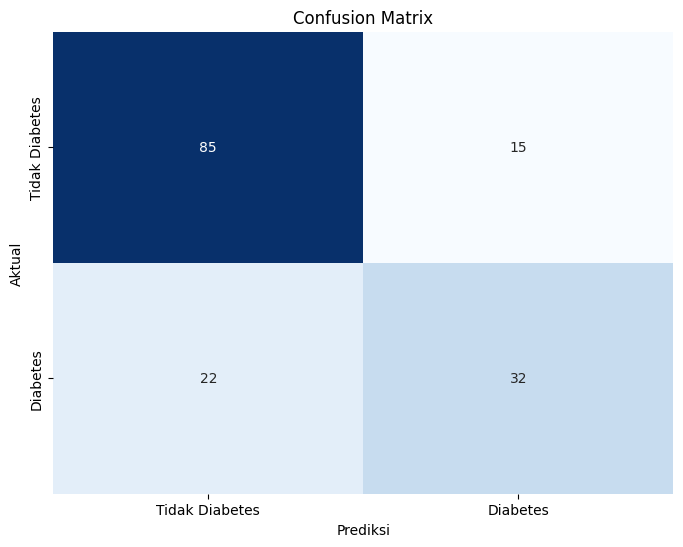

In [ ]:
import matplotlib.pyplot as plt
import seaborn as sns

plt.figure(figsize=(8, 6))
sns.heatmap(cm, annot=True, fmt="d", cmap="Blues", cbar=False,
            xticklabels=['Tidak Diabetes', 'Diabetes'],
            yticklabels=['Tidak Diabetes', 'Diabetes'])
plt.xlabel('Prediksi')
plt.ylabel('Aktual')
plt.title('Confusion Matrix')
plt.show()

Penjelasan metrik:

| Metrik           | Keterangan                                                        |
| ---------------- | ----------------------------------------------------------------- |
| Accuracy         | Persentase seluruh prediksi yang benar                            |
| Precision        | Ketepatan model saat memprediksi berisiko diabetes                |
| Recall           | Kemampuan model menemukan data yang benar-benar berisiko diabetes |
| F1-Score         | Rata-rata harmonik antara precision dan recall                    |
| Confusion Matrix | Tabel perbandingan prediksi benar dan salah                       |


Untuk kasus risiko kesehatan, recall penting karena model sebaiknya tidak terlalu banyak melewatkan data yang sebenarnya berisiko.

# 11 - Uji Prediksi Satu Data Baru

In [ ]:
sample_data = pd.DataFrame({
    "Pregnancies": [2],
    "Glucose": [130],
    "BloodPressure": [70],
    "SkinThickness": [25],
    "Insulin": [80],
    "BMI": [28.5],
    "DiabetesPedigreeFunction": [0.45],
    "Age": [35]
})

sample_scaled = scaler.transform(sample_data)

prediction = model.predict(sample_scaled)
probability = model.predict_proba(sample_scaled)

print("Hasil Prediksi:", prediction[0])
print("Probabilitas Tidak Diabetes:", probability[0][0])
print("Probabilitas Diabetes:", probability[0][1])

Hasil Prediksi: 0
Probabilitas Tidak Diabetes: 0.53
Probabilitas Diabetes: 0.47


Tambahkan interpretasi:

In [ ]:
if prediction[0] == 1:
    print("Interpretasi: Berisiko Diabetes")
else:
    print("Interpretasi: Tidak Berisiko Diabetes")

Interpretasi: Tidak Berisiko Diabetes


# 12 - Menyimpan Model dan Scaler

In [ ]:
with open("diabetes_model.pkl", "wb") as file:
    pickle.dump(model, file)

with open("scaler.pkl", "wb") as file:
    pickle.dump(scaler, file)

# 13 - Download File Model

In [ ]:
from google.colab import files

files.download("diabetes_model.pkl")
files.download("scaler.pkl")

<IPython.core.display.Javascript object>

<IPython.core.display.Javascript object>

<IPython.core.display.Javascript object>

<IPython.core.display.Javascript object>

Dua file ini nanti digunakan pada project API.

# 14 - Struktur File Setelah Tahap Model Selesai

In [ ]:
diabetes-risk-web-api/
│
├── model/
│   ├── diabetes_model.pkl
│   └── scaler.pkl
│
├── notebook/
│   └── training_diabetes_model.ipynb